# Overview:

**Aim:** The aim of this project is to develop an end-to-end fraud detection system using the IEEE-CIS Fraud Detection dataset. The project involves exploratory data analysis, feature engineering, machine learning model development, and deployment to identify potentially fraudulent transactions in real time.

**Use Cases:** This solution can be used by financial institutions, payment processors, and e-commerce platforms to automatically detect suspicious transactions, reduce financial losses, and improve customer security. 

# Exploratory Data Analysis (EDA)

The dataset used here is provided by Vesta Corportations, a company that provides e-commerce payment solutions. 

Kaggle Competition: https://www.kaggle.com/competitions/ieee-fraud-detection/overview

Data Overview provided in the competition:

**Transaction Table:**  
TransactionDT: timedelta from a given reference datetime (not an actual timestamp)  
TransactionAMT: transaction payment amount in USD  
ProductCD: product code, the product for each transaction  
card1 - card6: payment card information, such as card type, card category, issue bank, country, etc.  
addr: address  
dist: distance  
P_ and (R__) emaildomain: purchaser and recipient email domain  
C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.  
D1-D15: timedelta, such as days between previous transaction, etc.  
M1-M9: match, such as names on card and address, etc.  
Vxxx: Vesta engineered rich features, including ranking, counting, and other entity relations.  
Categorical Features: ProductCD, card1 - card6, addr1, addr2, P_emaildomain, R_emaildomain, M1 - M9   

**Identity Table:**  
Variables in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and pairwise dictionary will not be provided for privacy protection and contract agreement)  

Categorical Features: DeviceType, DeviceInfo, id_12 - id_38  

In this notebook, we will only explore the dataset in order to understand the data, features and correlations between features better.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We have two files - transaction and identity.
# These two are joined by transaction ID.
# Not all transactions have corresponding identity information.

train_transaction = pd.read_csv("data/train_transaction.csv")
train_identity = pd.read_csv("data/train_identity.csv")

In [6]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
train_transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [8]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [9]:
train_identity.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [ ]:
# Merge the datasets
train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

In [4]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## Missing Value Analysis

In [10]:
train_transaction[train_transaction.columns[train_transaction.isnull().any()]].isnull().sum().sort_values(ascending=False)

dist2    552913
D7       551623
D13      528588
D14      528353
D12      525823
          ...  
V302         12
V303         12
V304         12
V305         12
V306         12
Length: 374, dtype: int64

In [11]:
train_identity[train_identity.columns[train_identity.isnull().any()]].isnull().sum().sort_values(ascending=False)   

id_24         139486
id_25         139101
id_07         139078
id_08         139078
id_21         139074
id_26         139070
id_22         139064
id_27         139064
id_23         139064
id_18          99120
id_03          77909
id_04          77909
id_33          70944
id_10          69307
id_09          69307
id_30          66668
id_32          66647
id_34          66428
id_14          64189
DeviceInfo     25567
id_13          16913
id_16          14893
id_05           7368
id_06           7368
id_20           4972
id_19           4915
id_17           4864
id_31           3951
DeviceType      3423
id_02           3361
id_29           3255
id_11           3255
id_28           3255
id_15           3248
id_36           3248
id_35           3248
id_38           3248
id_37           3248
dtype: int64

In [12]:
transaction_missing = train_transaction.isnull().mean().sort_values(ascending=False) * 100
print("Percentage of missing transactions:\n", transaction_missing)

Percentage of missing transactions:
 dist2             93.628374
D7                93.409930
D13               89.509263
D14               89.469469
D12               89.041047
                    ...    
ProductCD          0.000000
TransactionAmt     0.000000
TransactionDT      0.000000
isFraud            0.000000
TransactionID      0.000000
Length: 394, dtype: float64


In [13]:
identity_missing = train_identity.isnull().mean().sort_values(ascending=False) * 100
print("Percentage of missing identities:\n", identity_missing)

Percentage of missing identities:
 id_24            96.708798
id_25            96.441868
id_07            96.425922
id_08            96.425922
id_21            96.423149
id_26            96.420375
id_23            96.416215
id_27            96.416215
id_22            96.416215
id_18            68.722137
id_04            54.016071
id_03            54.016071
id_33            49.187079
id_10            48.052110
id_09            48.052110
id_30            46.222432
id_32            46.207872
id_34            46.056034
id_14            44.503685
DeviceInfo       17.726179
id_13            11.726165
id_16            10.325654
id_06             5.108401
id_05             5.108401
id_20             3.447200
id_19             3.407681
id_17             3.372321
id_31             2.739318
DeviceType        2.373243
id_02             2.330257
id_28             2.256765
id_29             2.256765
id_11             2.256765
id_38             2.251912
id_35             2.251912
id_36             2.

In [16]:
results = []

for col in train.columns:

    missing_pct = train[col].isnull().mean()

    if missing_pct > 0.9:

        temp = train[col].isnull().astype(int)

        fraud_missing = train.loc[temp == 1, 'isFraud'].mean()   # Fraud when the column is missing
        fraud_present = train.loc[temp == 0, 'isFraud'].mean()   # Fraud when the column is present

        diff = abs(fraud_missing - fraud_present)

        results.append([
            col,
            missing_pct,
            fraud_missing,
            fraud_present,
            diff
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        'column',
        'missing_pct',
        'fraud_missing',
        'fraud_present',
        'difference'
    ]
)

results_df.sort_values(
    'difference',
    ascending=False
)

,column,missing_pct,fraud_missing,fraud_present,difference
1,D7,0.934099,0.026962,0.148778,0.121816
0,dist2,0.936284,0.030623,0.099158,0.068534
4,id_18,0.923607,0.031036,0.082792,0.051756
8,id_24,0.991962,0.034587,0.084685,0.050098
3,id_08,0.991271,0.034570,0.082638,0.048068
2,id_07,0.991271,0.034570,0.082638,0.048068
5,id_21,0.991264,0.034571,0.082574,0.048003
6,id_22,0.991247,0.034571,0.082414,0.047843
7,id_23,0.991247,0.034571,0.082414,0.047843
11,id_27,0.991247,0.034571,0.082414,0.047843


- This table shows us the fraud percentage when a particular value is present v/s missing.
- For instance, when D7 is missing, the fraud percentage is just 2%, whereas when it's present the fraud percentage is 14.8%, which is a huge difference.
- Sometimes just a value being present or absent could affect the analysis.

In [17]:
cols = results_df['column']
train[cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   dist2   37627 non-null  float64
 1   D7      38917 non-null  float64
 2   id_07   5155 non-null   float64
 3   id_08   5155 non-null   float64
 4   id_18   45113 non-null  float64
 5   id_21   5159 non-null   float64
 6   id_22   5169 non-null   float64
 7   id_23   5169 non-null   str    
 8   id_24   4747 non-null   float64
 9   id_25   5132 non-null   float64
 10  id_26   5163 non-null   float64
 11  id_27   5169 non-null   str    
dtypes: float64(10), str(2)
memory usage: 54.1 MB


In [18]:
# Missing Indicator 

high_missing_cols = [
    col
    for col in train.columns
        if train[col].isnull().mean() > 0.90
]

for col in high_missing_cols:
    train[f'{col}_missing'] = (
        train[col].isnull().astype(int)
    )

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15552\4209854071.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f'{col}_missing'] = (
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15552\4209854071.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[f'{col}_missing'] = (
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15552\4209854071.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joini

In [19]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_07_missing,id_08_missing,id_18_missing,id_21_missing,id_22_missing,id_23_missing,id_24_missing,id_25_missing,id_26_missing,id_27_missing
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,1,1,1,1,1,1,1,1,1,1
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,1,1
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,1,1,1,1,1,1,1,1,1,1
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,1,1,1,1,1,1,1,1,1,1
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,1,1,1,1,1,1,1,1,1,1


- We have created missing indicators for columns with more than 90% of the data missing.
- These indicators will serve as new predictors for our model and can also be used visualisation.

In [20]:
missing_analysis = []

for col in high_missing_cols:
    indicator = f'{col}_missing'

    fraud_rate = (
        train.groupby(indicator)['isFraud']
        .mean()
    )

    missing_analysis.append({
        'column': col,
        'fraud_not_missing': fraud_rate.get(0, np.nan),
        'fraud_missing': fraud_rate.get(1, np.nan),
        'difference': fraud_rate.get(1, np.nan) - fraud_rate.get(0, np.nan)
    })

missing_analysis = pd.DataFrame(missing_analysis)
missing_analysis = missing_analysis.sort_values(
    'difference',
    ascending=False
)

missing_analysis

,column,fraud_not_missing,fraud_missing,difference
9,id_25,0.081255,0.034584,-0.046670
10,id_26,0.082316,0.034573,-0.047744
6,id_22,0.082414,0.034571,-0.047843
7,id_23,0.082414,0.034571,-0.047843
11,id_27,0.082414,0.034571,-0.047843
5,id_21,0.082574,0.034571,-0.048003
2,id_07,0.082638,0.034570,-0.048068
3,id_08,0.082638,0.034570,-0.048068
8,id_24,0.084685,0.034587,-0.050098
4,id_18,0.082792,0.031036,-0.051756


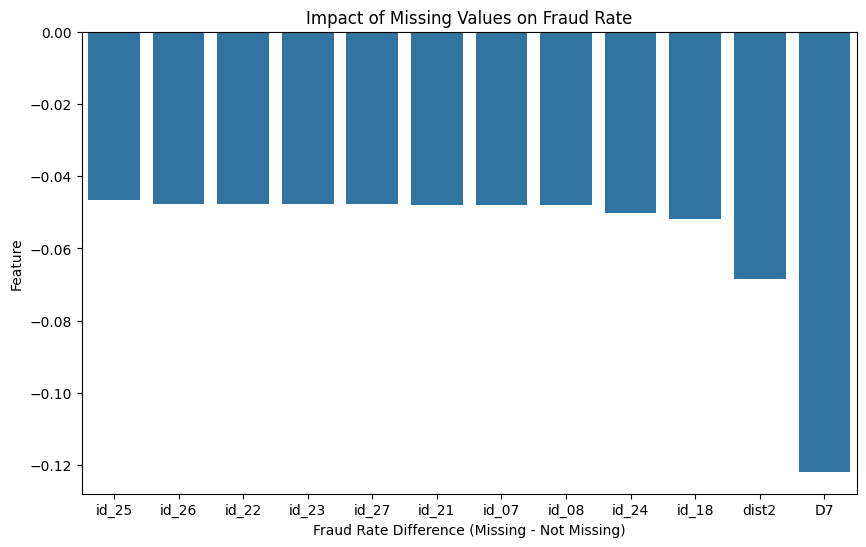

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing_analysis,
    x='column',
    y='difference'
)

plt.title('Impact of Missing Values on Fraud Rate')
plt.xlabel('Fraud Rate Difference (Missing - Not Missing)')
plt.ylabel('Feature')
plt.show()

## Class Imbalance Analysis

<Axes: xlabel='isFraud', ylabel='count'>

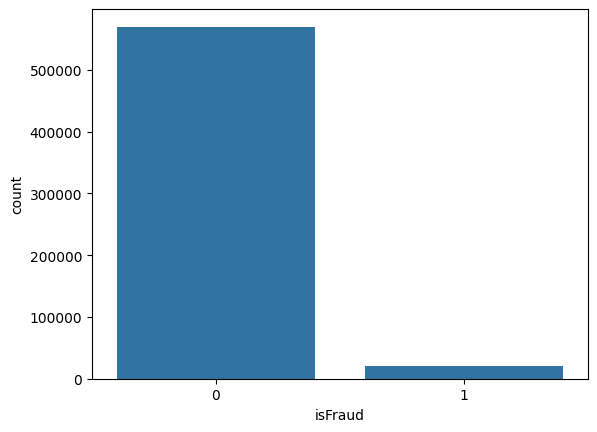

In [17]:
sns.countplot(data=train, x='isFraud')      # Highly imbalanced dataset

In [18]:
train['isFraud'].value_counts(normalize=True)*100 

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

- Only 3% of the transactions are fraudulent.
- We'll have to handle this imbalance while training our models and also during evaluation by using the right metrics.

## Fraud Rate by Categorical Features

These are the categorical features provided by the Vesta team here: https://www.kaggle.com/competitions/ieee-fraud-detection/data.

**Transaction:**  
ProductCD  
card1 - card6  
addr1, addr2  
P_emaildomain  
R_emaildomain  
M1 - M9  

**Identity:**  
DeviceType  
DeviceInfo  
id_12 - id_38  

In [16]:
cols = ['ProductCD', 'card1', 'card2', 'card3','card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 
        'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9',
        'DeviceType', 'DeviceInfo',]

for col in cols:
    print(f'{col}: {train[col].nunique()}')

ProductCD: 5
card1: 13553
card2: 500
card3: 114
card4: 4
card5: 119
card6: 4
addr1: 332
addr2: 74
P_emaildomain: 59
R_emaildomain: 60
M1: 2
M2: 2
M3: 2
M4: 3
M5: 2
M6: 2
M7: 2
M8: 2
M9: 2
DeviceType: 2
DeviceInfo: 1786


Checking columns which have fewer categories for better understanding.

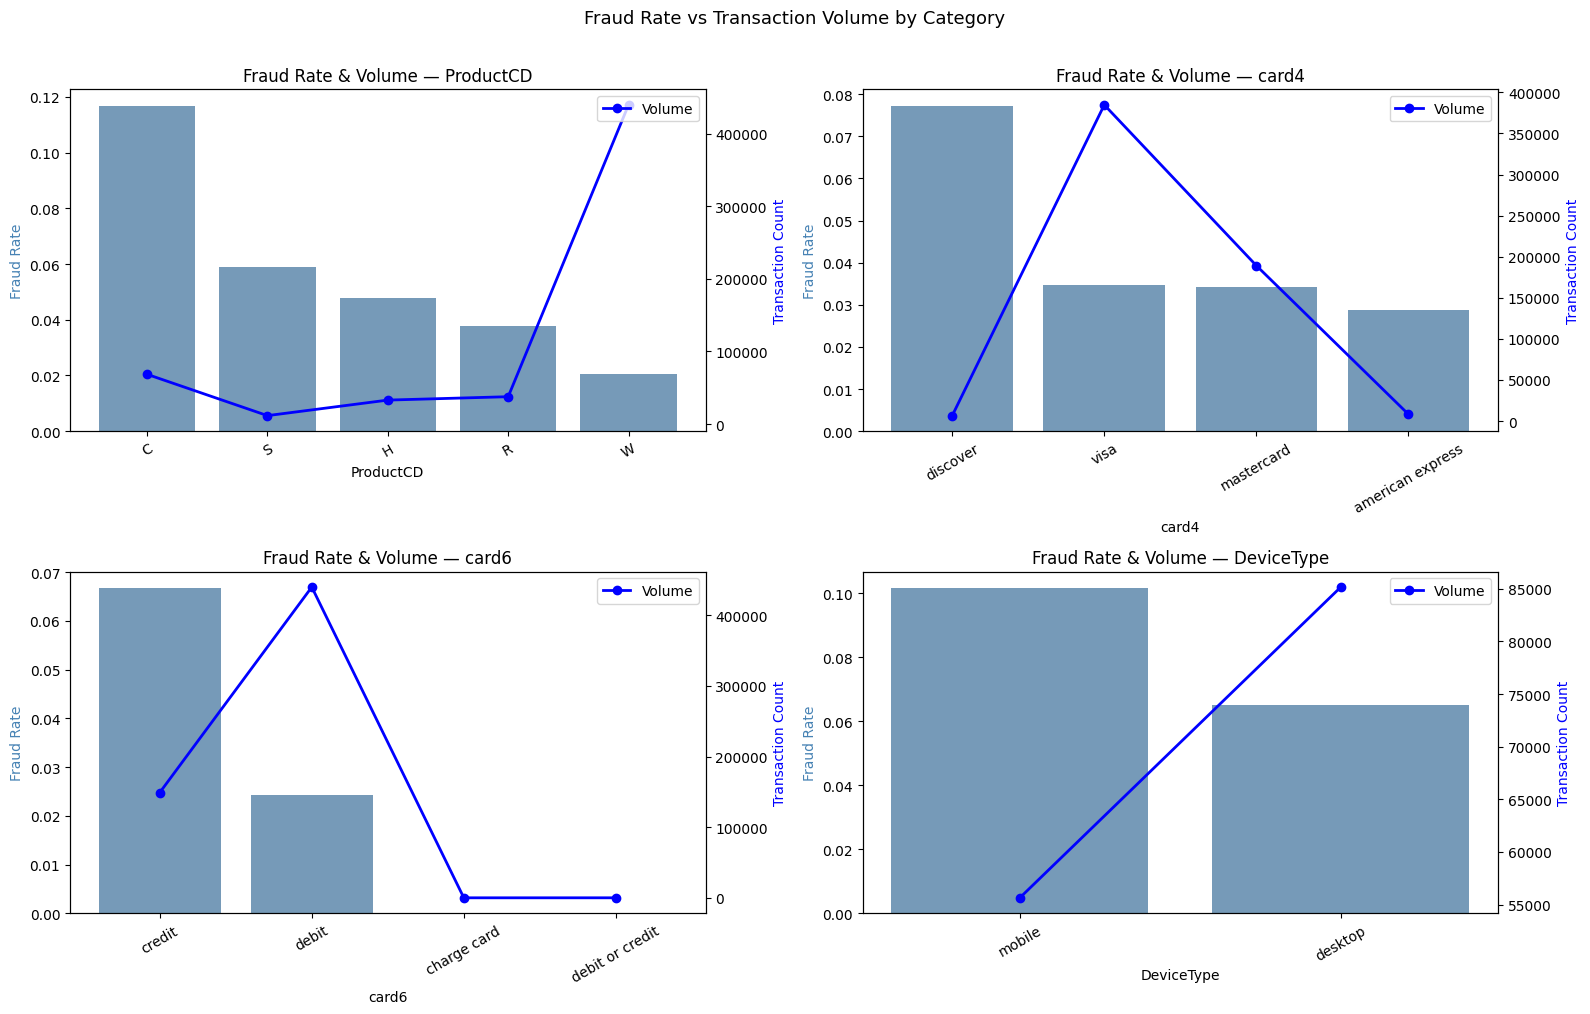

In [38]:
cols = ['ProductCD', 'card4', 'card6', 'DeviceType']  # low-cardinality first

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    stats = (
        train.groupby(col)['isFraud']
        .agg(['mean', 'count', 'sum'])
        .rename(columns={'mean': 'fraud_rate', 'count': 'total', 'sum': 'frauds'})
        .sort_values('fraud_rate', ascending=False)
        .reset_index()
    )

    ax1 = axes[i]
    ax2 = ax1.twinx()  # second y-axis for volume

    sns.barplot(data=stats, x=col, y='fraud_rate', ax=ax1, color='steelblue', alpha=0.8)
    ax2.plot(stats[col], stats['total'], color='blue', marker='o', linewidth=2, label='Volume')

    ax1.set_title(f'Fraud Rate & Volume — {col}')
    ax1.set_ylabel('Fraud Rate', color='steelblue')
    ax2.set_ylabel('Transaction Count', color='blue')
    ax1.tick_params(axis='x', rotation=30)
    ax2.legend(loc='upper right')

plt.suptitle('Fraud Rate vs Transaction Volume by Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

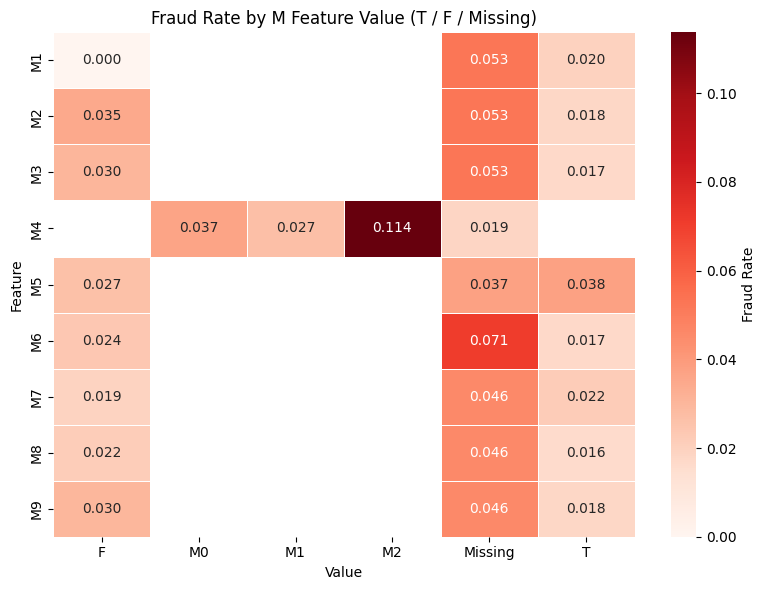

In [36]:
# M features are T/F/NaN — encode numerically for heatmap
m_cols = ['M1','M2','M3','M4','M5','M6','M7','M8','M9']

m_fraud = {}
for col in m_cols:
    m_fraud[col] = train.groupby(train[col].fillna('Missing'))['isFraud'].mean()

m_fraud_df = pd.DataFrame(m_fraud).T  # rows = M features, cols = T/F/Missing

plt.figure(figsize=(8, 6))
sns.heatmap(
    m_fraud_df,
    annot=True,
    fmt='.3f',
    cmap='Reds',
    linewidths=0.5,
    cbar_kws={'label': 'Fraud Rate'}
)
plt.title('Fraud Rate by M Feature Value (T / F / Missing)')
plt.xlabel('Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [39]:
# cols = ['ProductCD', 'card4', 'card6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType']

# for col in cols:
#     print('\n')
#     print(train.groupby(col)['isFraud'].mean())

In [46]:
id_cols = []

for i in range(12, 39):
    id_cols.append('id_' + str(i))

for col in id_cols:
    print(f'{col}: {train[col].nunique()}')

id_12: 2
id_13: 54
id_14: 25
id_15: 3
id_16: 2
id_17: 104
id_18: 18
id_19: 522
id_20: 394
id_21: 490
id_22: 25
id_23: 3
id_24: 12
id_25: 341
id_26: 95
id_27: 2
id_28: 2
id_29: 2
id_30: 75
id_31: 130
id_32: 4
id_33: 260
id_34: 4
id_35: 2
id_36: 2
id_37: 2
id_38: 2


In [47]:
id_cols = ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_32', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

for col in id_cols:
    print('\n')
    print(train.groupby(col)['isFraud'].mean())



id_12
Found       0.059836
NotFound    0.081683
Name: isFraud, dtype: float64


id_15
Found      0.105097
New        0.049244
Unknown    0.091885
Name: isFraud, dtype: float64


id_16
Found       0.107231
NotFound    0.048242
Name: isFraud, dtype: float64


id_23
IP_PROXY:ANONYMOUS      0.137255
IP_PROXY:HIDDEN         0.055829
IP_PROXY:TRANSPARENT    0.070221
Name: isFraud, dtype: float64


id_27
Found       0.082638
NotFound    0.000000
Name: isFraud, dtype: float64


id_28
Found    0.102752
New      0.052281
Name: isFraud, dtype: float64


id_29
Found       0.104463
NotFound    0.051338
Name: isFraud, dtype: float64


id_32
0.0     0.500000
16.0    0.222222
24.0    0.033917
32.0    0.066727
Name: isFraud, dtype: float64


id_34
match_status:-1    0.000000
match_status:0     0.050602
match_status:1     0.063651
match_status:2     0.039293
Name: isFraud, dtype: float64


id_35
F    0.122604
T    0.044683
Name: isFraud, dtype: float64


id_36
F    0.081885
T    0.035265
Name: isFraud

In [48]:
# Same pattern we used for M and D features
id_missing_analysis = []

for col in cols:
    indicator = train[col].isnull().astype(int)
    fraud_missing = train.loc[indicator == 1, 'isFraud'].mean()
    fraud_present = train.loc[indicator == 0, 'isFraud'].mean()

    id_missing_analysis.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'fraud_rate_missing': fraud_missing,
        'fraud_rate_present': fraud_present,
        'difference': fraud_missing - fraud_present
    })

id_missing_df = (
    pd.DataFrame(id_missing_analysis)
    .sort_values('difference', ascending=False)
)

print(id_missing_df)

   feature  missing_pct  fraud_rate_missing  fraud_rate_present  difference
7    id_32    86.861855            0.033555            0.044480   -0.010925
8    id_34    86.824771            0.033503            0.044791   -0.011289
4    id_27    99.124699            0.034571            0.082414   -0.047843
3    id_23    99.124699            0.034571            0.082414   -0.047843
2    id_16    78.098012            0.022791            0.078491   -0.055700
0    id_12    75.576083            0.020939            0.078470   -0.057532
6    id_29    76.127273            0.021009            0.079573   -0.058563
5    id_28    76.127273            0.021009            0.079573   -0.058563
1    id_15    76.126088            0.021001            0.079597   -0.058596
9    id_35    76.126088            0.021001            0.079597   -0.058596
10   id_36    76.126088            0.021001            0.079597   -0.058596
11   id_37    76.126088            0.021001            0.079597   -0.058596
12   id_38  

In [50]:
# id_fraud = {}

# for col in cols:
#     id_fraud[col] = (
#         train.groupby(train[col].fillna('Missing'))['isFraud']
#         .mean()
#     )

# id_fraud_df = pd.DataFrame(id_fraud).T

# plt.figure(figsize=(14, 8))
# sns.heatmap(
#     id_fraud_df,
#     annot=True,
#     fmt='.3f',
#     cmap='Reds',
#     linewidths=0.5,
#     cbar_kws={'label': 'Fraud Rate'}
# )
# plt.title('Fraud Rate by ID Feature Value')
# plt.xlabel('Value')
# plt.ylabel('Feature')
# plt.tight_layout()
# plt.show()

TypeError: '<' not supported between instances of 'float' and 'str'

In [20]:
cols = ['P_emaildomain', 'R_emaildomain']
for col in cols:
    print('\n')
    print(train.groupby(col)['isFraud'].mean())



P_emaildomain
aim.com             0.126984
anonymous.com       0.023217
aol.com             0.021811
att.net             0.007439
bellsouth.net       0.027763
cableone.net        0.018868
centurylink.net     0.000000
cfl.rr.com          0.000000
charter.net         0.030637
comcast.net         0.031187
cox.net             0.020818
earthlink.net       0.021401
embarqmail.com      0.034615
frontier.com        0.028571
frontiernet.net     0.025641
gmail               0.022177
gmail.com           0.043542
gmx.de              0.000000
hotmail.co.uk       0.000000
hotmail.com         0.052950
hotmail.de          0.000000
hotmail.es          0.065574
hotmail.fr          0.000000
icloud.com          0.031434
juno.com            0.018634
live.com            0.027622
live.com.mx         0.054740
live.fr             0.000000
mac.com             0.032110
mail.com            0.189624
me.com              0.017740
msn.com             0.021994
netzero.com         0.000000
netzero.net         0.00510

It's better to check the fraud rates of domains that have at least 100 transactions, this can remove all the domains which are rarely used.  

In [25]:
email_stats = (
    train.groupby('P_emaildomain')['isFraud']
    .agg(['count','sum','mean'])
)

email_stats = email_stats[
    email_stats['count'] >= 100
]

email_stats.sort_values(
    'mean',
    ascending=False
).head(15)

,count,sum,mean
P_emaildomain,,,
mail.com,559,106,0.189624
outlook.es,438,57,0.130137
aim.com,315,40,0.126984
outlook.com,5096,482,0.094584
hotmail.es,305,20,0.065574
live.com.mx,749,41,0.054740
hotmail.com,45250,2396,0.052950
gmail.com,228355,9943,0.043542
yahoo.fr,143,5,0.034965


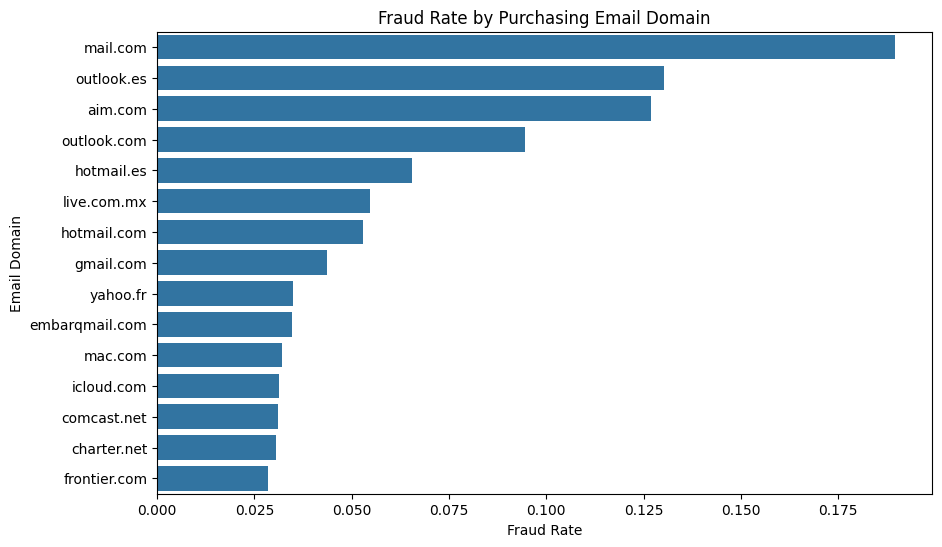

In [26]:
top_domains = (
    email_stats
    .sort_values('mean', ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_domains,
    x='mean',
    y='P_emaildomain'
)

plt.xlabel('Fraud Rate')
plt.ylabel('Email Domain')
plt.title('Fraud Rate by Purchasing Email Domain')
plt.show()

In [27]:
cols = ['addr1', 'addr2']

for col in cols:
    print('\n')
    print(train.groupby(col)['isFraud'].mean())



addr1
100.0    0.000000
101.0    0.000000
102.0    0.000000
104.0    0.000000
105.0    0.000000
           ...   
530.0    0.000000
531.0    0.000000
535.0    0.000000
536.0    0.161812
540.0    0.000000
Name: isFraud, Length: 332, dtype: float64


addr2
10.0     1.0
13.0     0.0
14.0     0.0
15.0     0.0
16.0     0.0
        ... 
97.0     0.0
98.0     0.0
100.0    0.0
101.0    0.0
102.0    0.0
Name: isFraud, Length: 74, dtype: float64


## Transaction Amount Analysis

<Axes: xlabel='TransactionAmt', ylabel='Count'>

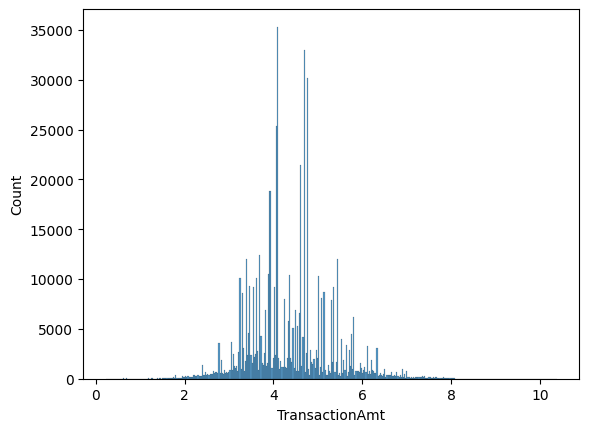

In [21]:
sns.histplot(
    np.log1p(train['TransactionAmt'])
)

<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

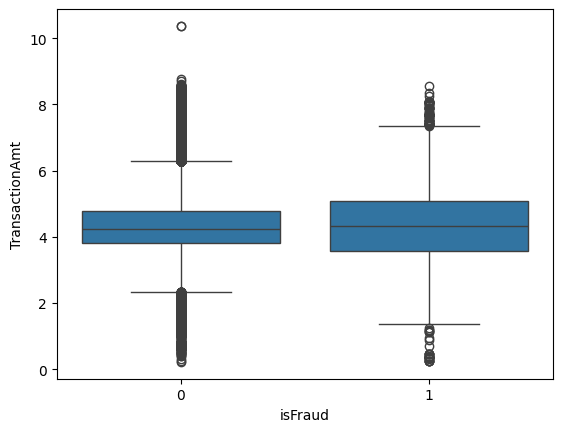

In [22]:
sns.boxplot(
    x='isFraud',
    y=np.log1p(train['TransactionAmt']),
    data=train
)

Analysis:
- The median of fraudulent transactions is slightly more than non-fraudulent transactions, showing the transaction amount is slightly high in case of frauds.
- The transaction amount for fraudulent data is widespread as compared to non-fraudulent (can be seen from the larger IQR).
- We can also see an outlier in non-fraudulent data. This could affect our predictions going forward. 

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\1117458036.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['AmtBin'] = pd.qcut(


<Axes: xlabel='AmtBin'>

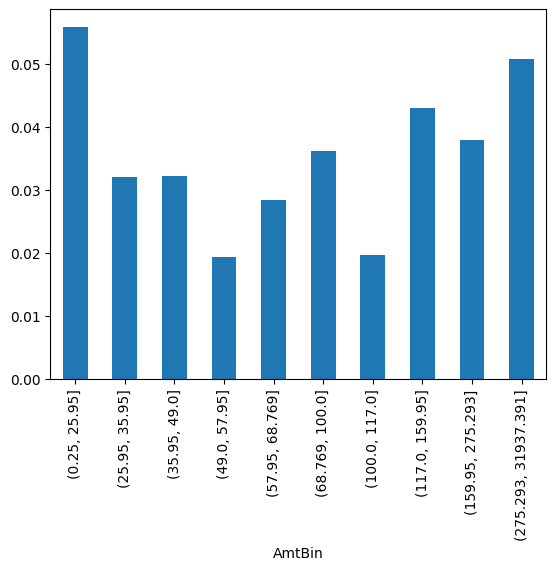

In [23]:
# Create bins
train['AmtBin'] = pd.qcut(
    train['TransactionAmt'],
    q=10,
    duplicates='drop'
)

# Group by the bins
fraud_by_amt = (
    train.groupby('AmtBin')['isFraud']
    .mean()
)

# Plot
fraud_by_amt.plot(kind='bar')

- The smallest transactions have the highest fraud rate. And secondly, the highest transactions have the highest fraud rate. 
- An example of small transactions is when a scammer tests a stolen card if it's active. Once it's confirmed, they mostly go for larger transactions.
The middle ranges appear safest.

In [24]:
train.groupby('isFraud')['TransactionAmt'].agg([
    'count',
    'mean',
    'median',
    'std'
])

,count,mean,median,std
isFraud,,,,
0,569877,134.511665,68.5,239.395078
1,20663,149.244779,75.0,232.212163


In [25]:
# Top 20 largest transactions
train.nlargest(
    20,
    'TransactionAmt'
)[['TransactionAmt','isFraud']]

,TransactionAmt,isFraud
274336,31937.391,0
274339,31937.391,0
296021,6450.970,0
248413,6085.230,0
384603,5543.230,0
275529,5420.000,0
275535,5420.000,0
584767,5366.820,0
303106,5279.950,0
315172,5279.950,0


- It is interesting that most of the top transactions are not fraudulent. There's just one fraud in the top 20 largest transactions. 
- This is probably because larger amounts require an email or mobile verification. 

In [26]:
# Top 20 smallest transactions
train.nsmallest(
    20,
    'TransactionAmt'
)[['TransactionAmt','isFraud']]

,TransactionAmt,isFraud
374299,0.251,0
367961,0.272,0
29976,0.292,1
205370,0.292,1
205382,0.292,1
205865,0.292,1
205872,0.292,1
205393,0.350,1
492354,0.364,0
41932,0.424,1


- On the other hand, we have a lot of transactions with small amounts that are fraudulent.
- Another interesting point is most of the transaction amounts are odd and basically the same.
- These are used to test stolen card numbers on e-commerce sites to see if the card is active, unblocked, and has an available limit before attempting larger purchases.

## Temporal Analysis

In [28]:
# train['TransactionDay'] = (
#     train['TransactionDT'] // (24*60*60)
# )

In [29]:
train['TransactionDT'].describe()

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64

In [30]:
train['TransactionDT'].min(), train['TransactionDT'].max()

(np.int64(86400), np.int64(15811131))

In [31]:
train['TransactionDT'].max() / train['TransactionDT'].min()  # The dataset spans roughly 183 days of transactions

np.float64(182.99920138888888)

In [32]:
# Get the transaction days
train['TransactionDay'] = (
    train['TransactionDT'] // 86400
).astype(int)

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\3512992190.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionDay'] = (


<Axes: xlabel='TransactionDay'>

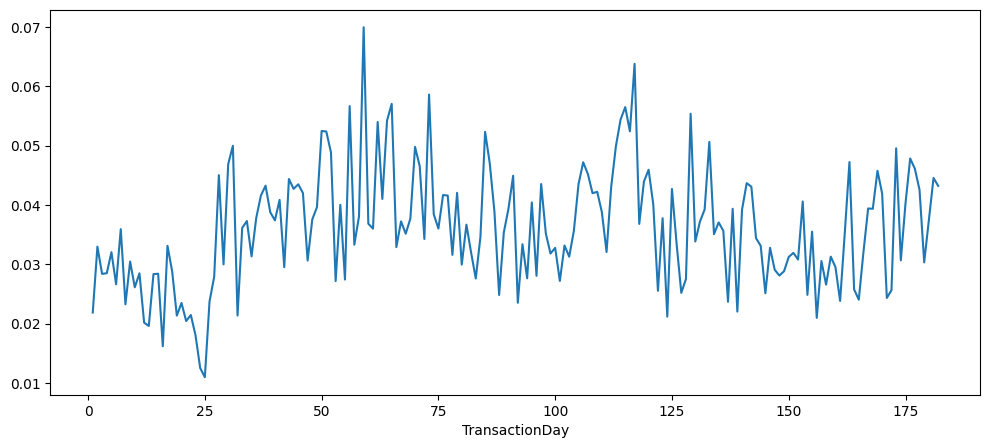

In [33]:
daily_fraud = (
    train.groupby('TransactionDay')['isFraud']
    .mean()
)

daily_fraud.plot(figsize=(12,5))

- There are a few spikes indicating there were few days of increased fraud activity. 
- However, there is no proper trend over time.

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\2158502736.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionHour'] = (


<Axes: xlabel='TransactionHour'>

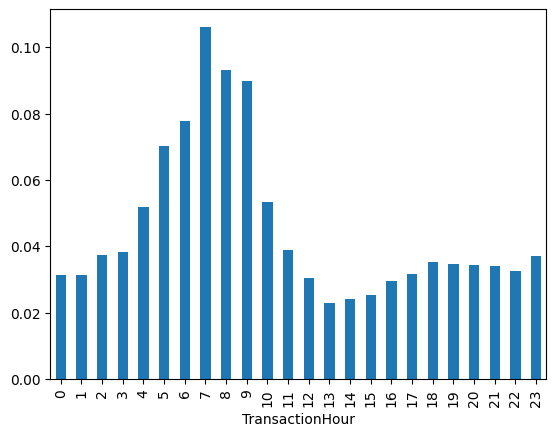

In [34]:
train['TransactionHour'] = (
    (train['TransactionDT'] // 3600) % 24
).astype(int)

hourly_fraud = (
    train.groupby('TransactionHour')['isFraud']
    .mean()
)

hourly_fraud.plot(kind='bar')

In [35]:
hourly_fraud.sort_values(ascending=False)

TransactionHour
7     0.106102
8     0.093014
9     0.089956
6     0.077743
5     0.070302
10    0.053212
4     0.051890
11    0.038816
3     0.038314
2     0.037483
23    0.036997
18    0.035231
19    0.034738
20    0.034273
21    0.034005
22    0.032694
17    0.031530
0     0.031380
1     0.031314
12    0.030439
16    0.029511
15    0.025399
14    0.024216
13    0.022889
Name: isFraud, dtype: float64

- Hours 5 to 9 have the highest fraud activity, peak at hour 6, showing time of the day matters.
- However, we do not have the exact hours and timezone as we have just calculated this from timedelta. So the actual hours could be different, most likely night hours. 

In [36]:
train.groupby('TransactionHour').size()

TransactionHour
0     37795
1     32797
2     26732
3     20802
4     14839
5      9701
6      6007
7      3704
8      2591
9      2479
10     3627
11     6827
12    12451
13    20315
14    28328
15    33859
16    38698
17    40723
18    41639
19    42115
20    41782
21    41641
22    41139
23    39949
dtype: int64

In [37]:
hourly_stats = (
    train.groupby('TransactionHour')['isFraud']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={
        'count': 'transactions',
        'sum': 'frauds',
        'mean': 'fraud_rate'
    })
)

hourly_stats.sort_values(
    'fraud_rate',
    ascending=False
)

,transactions,frauds,fraud_rate
TransactionHour,,,
7,3704,393,0.106102
8,2591,241,0.093014
9,2479,223,0.089956
6,6007,467,0.077743
5,9701,682,0.070302
10,3627,193,0.053212
4,14839,770,0.051890
11,6827,265,0.038816
3,20802,797,0.038314


- We can trust the fraud rates as we have quite a few transactions during the peak hours. If we had like 10 transactions with 5 frauds, the 50% fraud rate wouldn't have made sense. But it looks useful.
- The highest fraud hours are also the lowest volume hours. This could possibly mean more fraudsters are active when normal customers are inactive.
- TransactionHour looks like a good feature for predictions.

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_15792\186075757.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['TransactionWeek'] = (


<Axes: xlabel='TransactionWeek'>

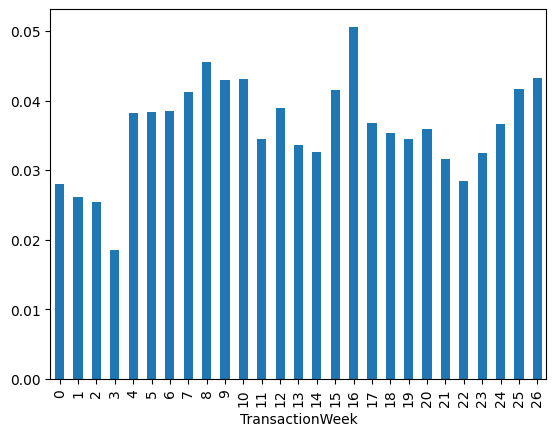

In [38]:
train['TransactionWeek'] = (
    train['TransactionDT'] // (86400 * 7)
).astype(int)

weekly_fraud = (
    train.groupby('TransactionWeek')['isFraud']
    .mean()
)

weekly_fraud.plot(kind='bar')

- There are no weekly patterns visible. 
- Some weeks show increased fraud activity, but there is no clear increase or decrease over the weeks.

## Correlation Analysis

### 1. Correlation of Numerical Features with the Target variable

In [46]:
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

target_corr = (
    train[numeric_cols].corrwith(train['isFraud']).sort_values(key=abs, ascending=False)
)

target_corr.head(30)

isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
V52        0.239469
V157       0.234866
V155       0.234199
V230       0.231740
V199       0.231024
V148       0.228891
V51        0.223191
V171       0.216508
V40        0.212442
V243       0.210238
dtype: float64

- Most of the derived features, V257, V246, etc have high correlation with the target variable. 
- We will analyse the V features in a separate block. 

### 2. Correlation Between Numerical Features 

In [47]:
corr_matrix = train[numeric_cols].corr().abs()

high_corr = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .sort_values(ascending=False)
)

high_corr.head(20)

id_22_missing  id_27_missing      1.000000
id_23_missing  id_27_missing      1.000000
id_07_missing  id_08_missing      1.000000
id_22_missing  id_23_missing      1.000000
D9             TransactionHour    1.000000
D4             D12                0.999999
TransactionDT  TransactionDay     0.999982
V95            V322               0.999949
V96            V323               0.999948
V97            V324               0.999947
V101           V322               0.999698
V279           V322               0.999624
V95            V101               0.999594
V279           V293               0.999568
C7             C12                0.999489
V280           V324               0.999464
id_26_missing  id_27_missing      0.999414
id_22_missing  id_26_missing      0.999414
id_23_missing  id_26_missing      0.999414
V293           V322               0.999403
dtype: float64

- There is high correlation between certain features like D4 and D12, V95 and V322, showing both these features have similar things to contribute to our prediction.
- D9 and TransactionHour have a correlation of 1, suggesting D9 is probably derived from the timestamp.

## V-Feature Analysis

In [18]:
v_feats = train.loc[:,'V1':'V339'].copy()
v_feats['isFraud'] = train['isFraud']
v_feats.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V331,V332,V333,V334,V335,V336,V337,V338,V339,isFraud
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [19]:
# Correlation of each V feature with target
v_target_corr = (
    v_feats.corr()['isFraud']
    .drop('isFraud')
    .sort_values(key=abs, ascending=False)
)

print("Top 20 V features correlated with fraud:")
print(v_target_corr.head(20))


Top 20 V features correlated with fraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_16496\1848603455.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_v.values, y=top_v.index, palette=colors)


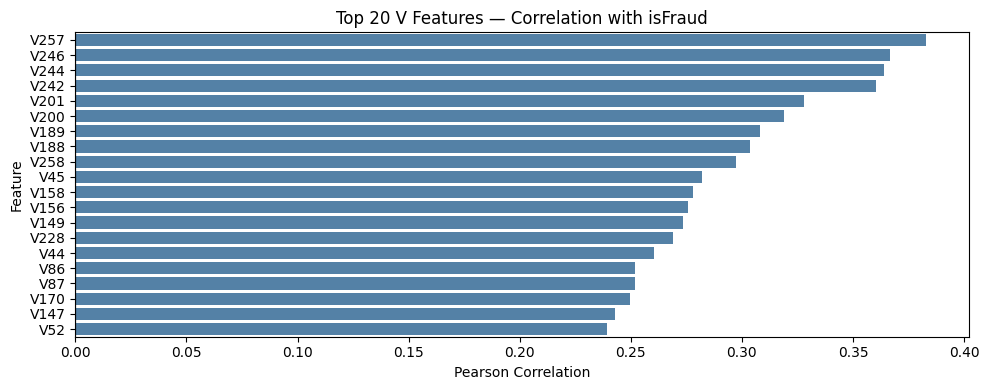

In [29]:
top_v = v_target_corr.head(20)

plt.figure(figsize=(10, 4))
colors = ['red' if x < 0 else 'steelblue' for x in top_v.values]
sns.barplot(x=top_v.values, y=top_v.index, palette=colors)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 V Features — Correlation with isFraud')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

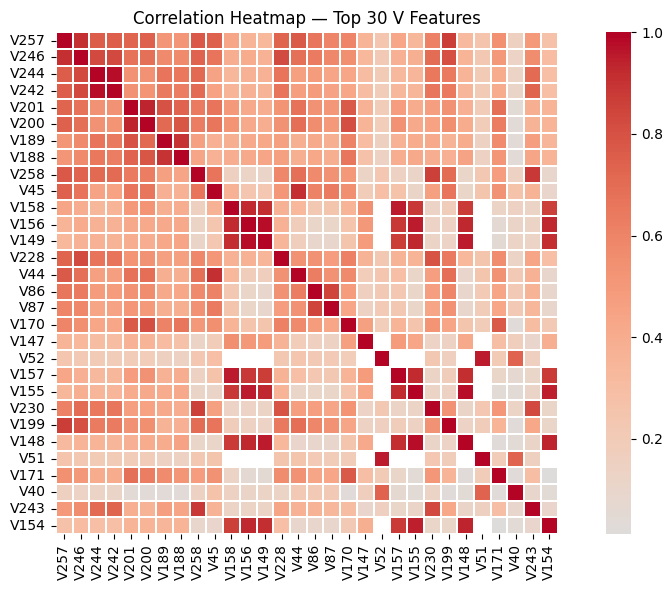

In [28]:
top_v_cols = v_target_corr.head(30).index.tolist()

plt.figure(figsize=(10, 6))
corr_matrix = v_feats[top_v_cols].corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot=False,       # too many features to annotate legibly
    square=True
)

plt.title('Correlation Heatmap — Top 30 V Features')
plt.tight_layout()
plt.show()

The heatmap reveals clear cluster structure in the V features — groups of highly inter-correlated variables likely representing the same underlying signal. In feature engineering, we can select one representative per cluster or create aggregations rather than using all 339 features. This reduces multicollinearity and dimensionality.

Some distinct clusters observed:  
{V257, V246, V244, V242}  
{V201, V200, V189, V188}  
{V158, V156, V149}  
{V86, V87}  
{V157, V155, V148}  
{V52, V147, V170}  

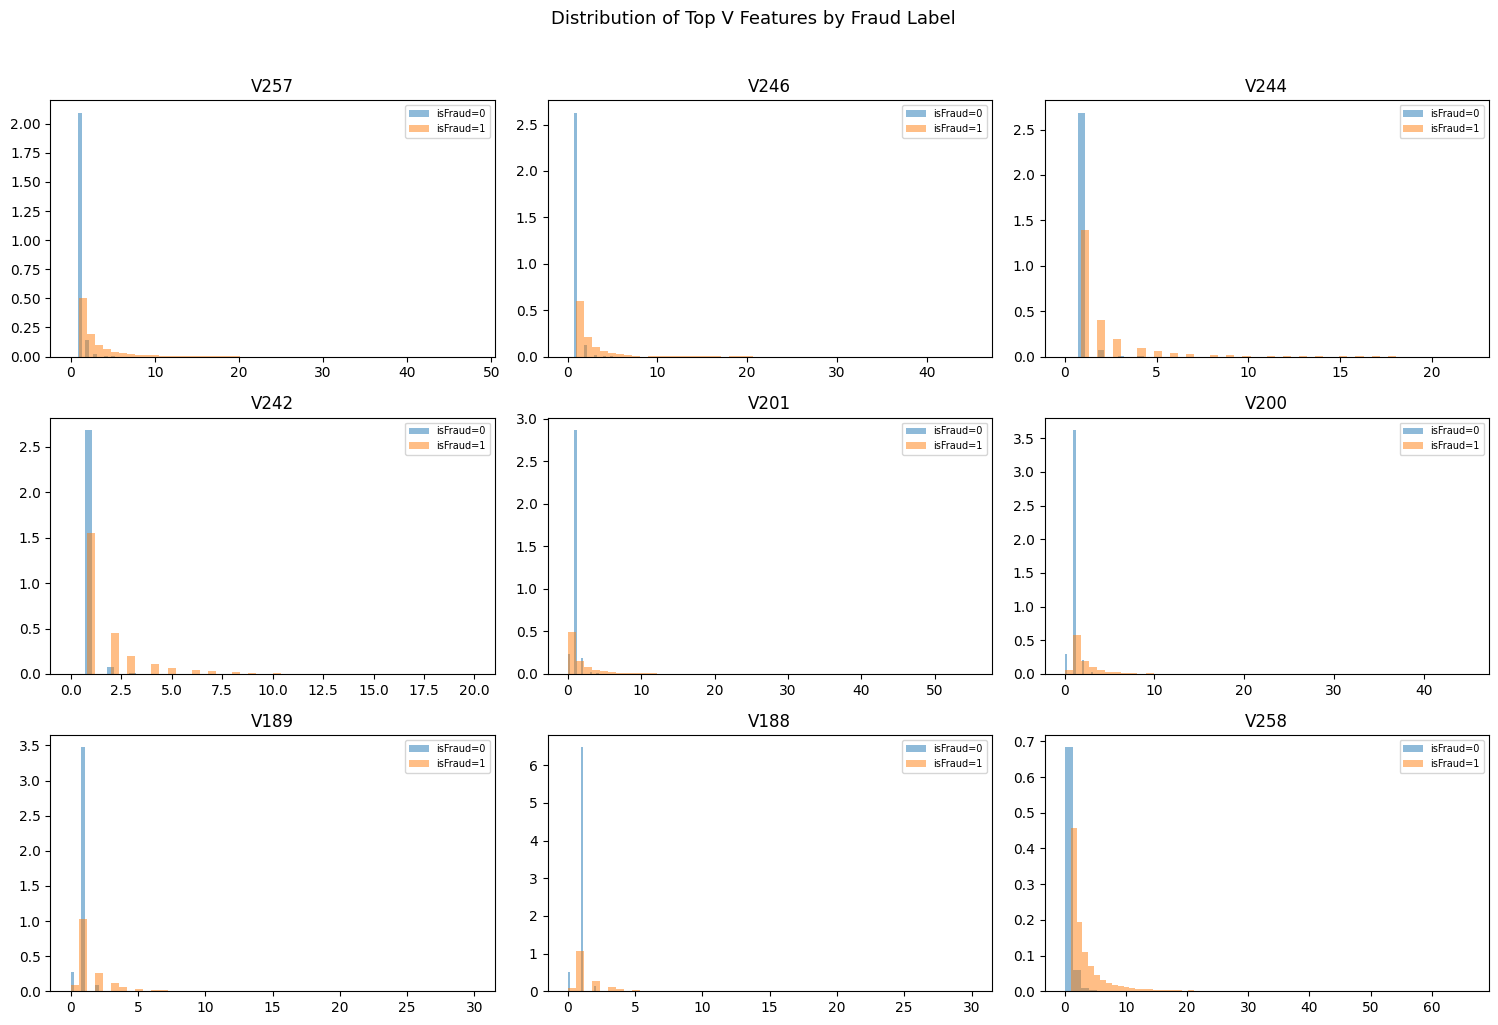

In [22]:
# Pick top 9 by absolute correlation for a clean 3x3 grid
top9 = v_target_corr.head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top9):
    for label, grp in v_feats.groupby('isFraud'):
        axes[i].hist(
            grp[col].dropna(),
            bins=50,
            alpha=0.5,
            density=True,
            label=f'isFraud={label}'
        )
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Top V Features by Fraud Label', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

All top V features show a heavy right-skewed distribution. The key pattern is:
- Non-fraud (blue): extremely concentrated at low values (near 0-1), very sharp spike
- Fraud (orange): flatter, more spread out, with a longer right tail

This means fraud transactions tend to have HIGHER values on these V features.

## C-Feature Analysis

In [6]:
## C Feature Analysis

c_cols = [col for col in train.columns if col.startswith('C')]
print(f"C features: {c_cols}")

C features: ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


In [7]:
# Fraud rate and distribution stats per C feature
c_analysis = []

for col in c_cols:
    c_analysis.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'mean_fraud': train.loc[train['isFraud'] == 1, col].mean(),
        'mean_legit': train.loc[train['isFraud'] == 0, col].mean(),
        'ratio': train.loc[train['isFraud'] == 1, col].mean() / train.loc[train['isFraud'] == 0, col].mean(),
        'corr_with_target': train[col].corr(train['isFraud'])
    })

c_analysis_df = pd.DataFrame(c_analysis).sort_values('corr_with_target', ascending=False)
print(c_analysis_df)

   feature  missing_pct  mean_fraud  mean_legit     ratio  corr_with_target
1       C2          0.0   45.509413   14.173283  3.210930          0.037229
7       C8          0.0   21.242608    4.560881  4.657567          0.032139
11     C12          0.0   18.597541    3.549703  5.239183          0.031905
0       C1          0.0   35.535740   13.314952  2.668860          0.030570
3       C4          0.0   15.077336    3.693878  4.081710          0.030382
9      C10          0.0   19.493926    4.723526  4.126986          0.028396
6       C7          0.0   11.977157    2.517484  4.757591          0.028160
10     C11          0.0   23.857475    9.747825  2.447467          0.027484
5       C6          0.0   16.923148    8.786377  1.926067          0.020909
13     C14          0.0   10.356047    8.220491  1.259784          0.007921
2       C3          0.0    0.000242    0.005840  0.041436         -0.006833
12     C13          0.0   24.967768   32.814474  0.760877         -0.011146
4       C5  

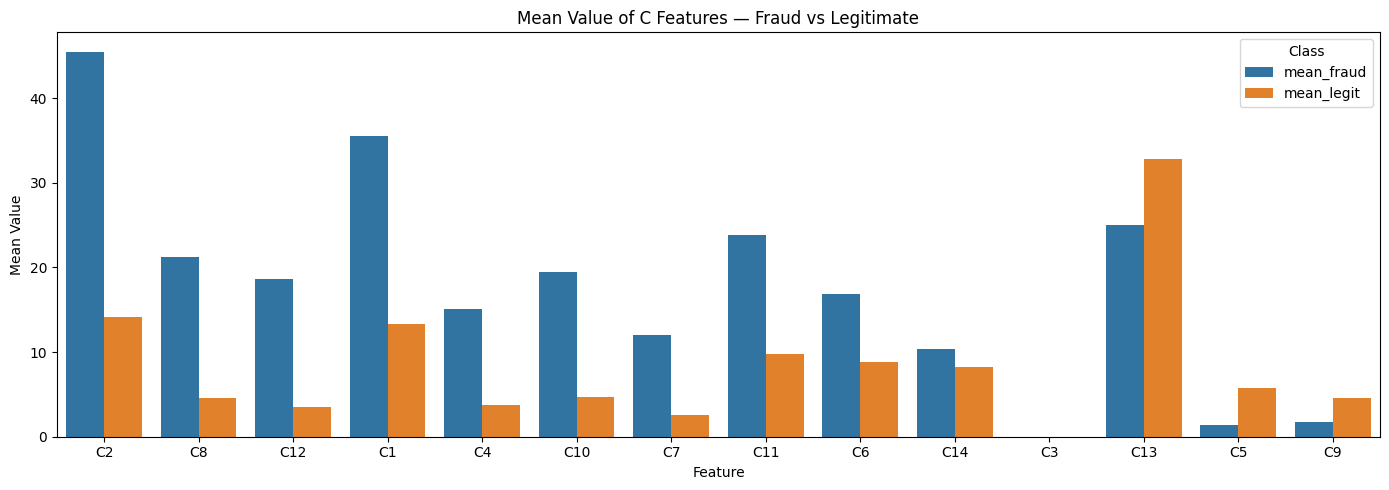

In [11]:
# Visualise: mean value for fraud vs legit, side by side
c_analysis_df_melted = c_analysis_df.melt(
    id_vars='feature',
    value_vars=['mean_fraud', 'mean_legit'],
    var_name='class',
    value_name='mean_value'
)

plt.figure(figsize=(14, 5))
sns.barplot(data=c_analysis_df_melted, x='feature', y='mean_value', hue='class')
plt.title('Mean Value of C Features — Fraud vs Legitimate')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

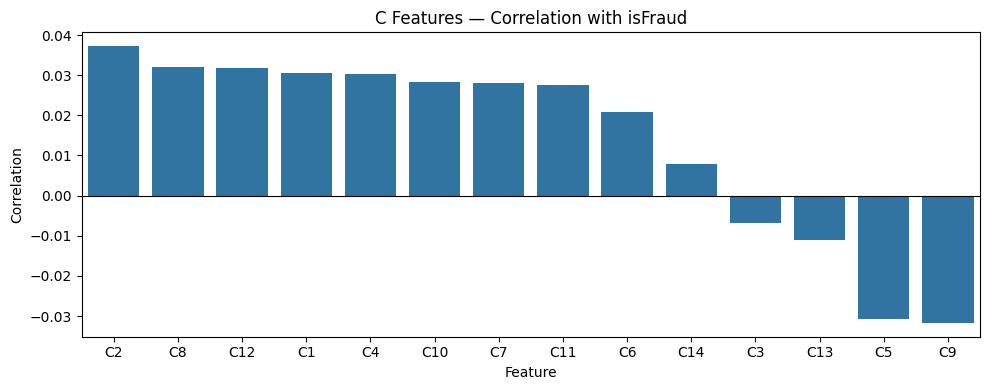

In [12]:
# Correlation of C features with target
c_corr = train[c_cols].corrwith(train['isFraud']).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=c_corr.index, y=c_corr.values)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('C Features — Correlation with isFraud')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

## D-Feature Analysis

These are timedelta features, such as days between transactions, etc.  
As we have seen above, these columns have too many missing values. So we need to consider that while analysing these features.

In [24]:
## D Feature Analysis

d_cols = [col for col in train.columns if (col.startswith('D')) and (col not in ['DeviceType', 'DeviceInfo'])]
print(f"D features: {d_cols}")

# 1. Missingness summary — already informative in itself
d_missing_fraud = []

for col in d_cols:
    indicator = train[col].isnull().astype(int)
    fraud_when_missing = train.loc[indicator == 1, 'isFraud'].mean()
    fraud_when_present = train.loc[indicator == 0, 'isFraud'].mean()
    
    d_missing_fraud.append({
        'feature': col,
        'missing_pct': train[col].isnull().mean() * 100,
        'fraud_rate_when_missing': fraud_when_missing,
        'fraud_rate_when_present': fraud_when_present,
        'difference': fraud_when_missing - fraud_when_present
    })

d_missing_df = pd.DataFrame(d_missing_fraud).sort_values('missing_pct', ascending=False)
d_missing_df

D features: ['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15']


,feature,missing_pct,fraud_rate_when_missing,fraud_rate_when_present,difference
6,D7,93.409930,0.026962,0.148778,-0.121816
12,D13,89.509263,0.026156,0.110360,-0.084203
13,D14,89.469469,0.025456,0.115989,-0.090532
11,D12,89.041047,0.024847,0.117403,-0.092557
5,D6,87.606767,0.025022,0.105456,-0.080434
7,D8,87.312290,0.024895,0.104463,-0.079568
8,D9,87.312290,0.024895,0.104463,-0.079568
4,D5,52.467403,0.031574,0.038760,-0.007186
1,D2,47.549192,0.045560,0.025408,0.020151
10,D11,47.293494,0.052122,0.019617,0.032505


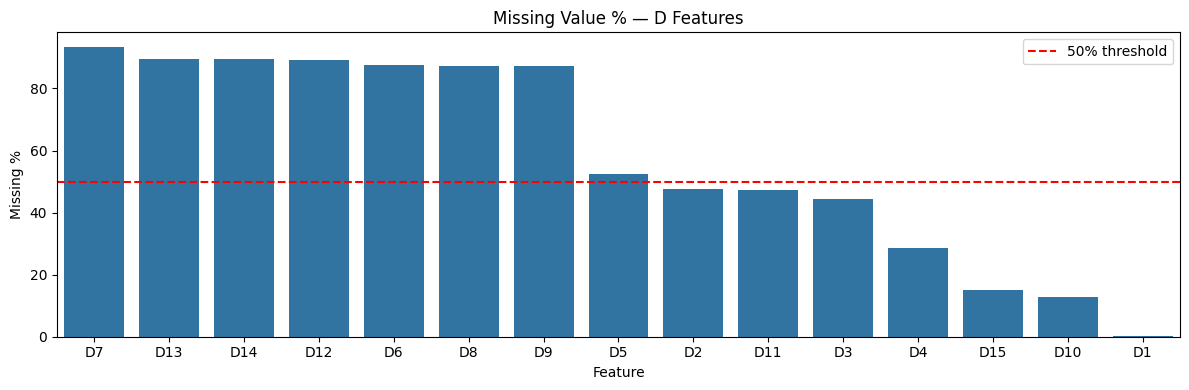

In [25]:
# For D features, missing % matters a lot — first visualise it
d_missing = train[d_cols].isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(12, 4))
sns.barplot(x=d_missing.index, y=d_missing.values)
plt.title('Missing Value % — D Features')
plt.ylabel('Missing %')
plt.xlabel('Feature')
plt.axhline(50, color='red', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_16556\45310670.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=d_corr.index, y=d_corr.values, palette=colors)
C:\Users\Mansi Jadhav\AppData\Local\Temp\ipykernel_16556\45310670.py:7: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=d_corr.index, y=d_corr.values, palette=colors)


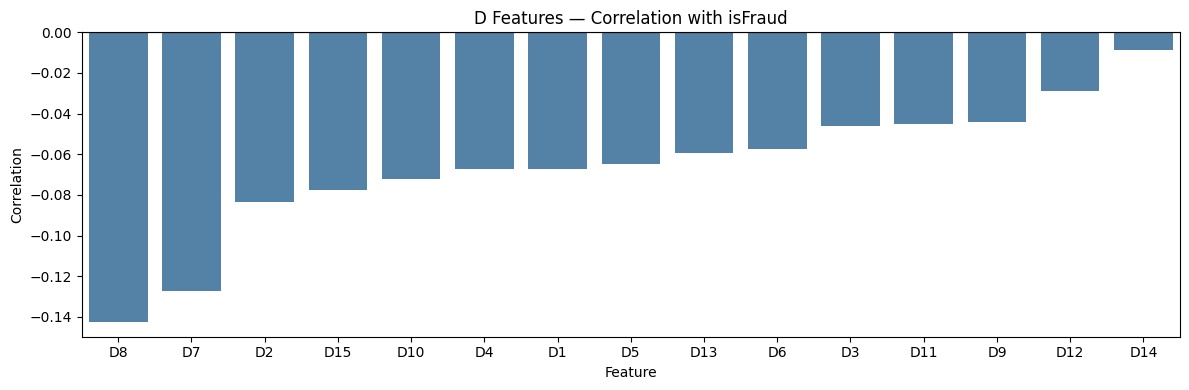

In [34]:
# D feature correlations with target
d_corr = train[d_cols].corrwith(train['isFraud']).sort_values(key=abs, ascending=False)

plt.figure(figsize=(12, 4))
# colors = ['red' if x < 0 else 'steelblue' for x in d_corr.values]
colors = ['steelblue']
sns.barplot(x=d_corr.index, y=d_corr.values, palette=colors)
# sns.barplot(x=d_corr.index, y=d_corr.values, hue=x, legend=False)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('D Features — Correlation with isFraud')
plt.xlabel('Feature')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()